In [1]:
from langgraph.graph import StateGraph, START , END
from typing import TypedDict , List
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field 
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0, 
    max_tokens=None
)

In [4]:
class EvaluationSchema(BaseModel):
    feedback : str =  Field(description="Detailed Feedback on the essay")
    score : int = Field(description="Score out of 10",ge=0 ,le=10)
    


In [5]:
strucutred_model=model.with_structured_output(EvaluationSchema)

In [6]:
essay=""" The moment was significant, even if few recognised it at the time. Here was an Indian thinker not merely demanding reform but arriving in the imperial metropole with his own diagnosis of empire’s ethical failings. His cloak may have seemed out of place in the foggy streets of London, but his message was piercingly modern: power must be near to be fair. His presence in England wasn’t just diplomatic: it was symbolic. Roy was stepping into the heart of empire not merely to protest, but to propose. As he would argue, critique from a colonial subject wasn’t a contradiction; it was a form of ethical intervention. And perhaps more radically, he believed that Britain had something to gain by listening. Roy did not call for rebellion, but for reform grounded in empathy, knowledge and responsibility. What he offered was a vision of rule based not on domination, but on ethical presence.

To understand Roy’s radicalism, one must first recognise the peculiar nature of the empire he addressed. The British East India Company governed not as a typical colonial state, but as a multinational corporation with a private army. Its rule was bureaucratic, extractive and often unaccountable. In this world, Roy’s voice stood out not simply because it was Indian, but because it was reasoned, comparative and universalist. He spoke the language of rights and governance, of moral duty and political proximity: a language the British claimed to understand, and that Roy used to hold them to account.

On the surface, the Exposition looked like a dry report. But inside was a surprising claim: the greatest problem with British rule in India wasn’t just oppression or corruption. It was distance. Courts operated in languages that ordinary people couldn’t understand. Administrators rarely stayed long enough in one place to learn how it worked. And decisions were made far away, in Calcutta or London, by people with no connection to the lives they affected."""

In [7]:
prompt = f"Evaluate the following essay and provide feedback and a score out of 10:\n\n{essay}"
print( strucutred_model.invoke(prompt).feedback)
print( strucutred_model.invoke(prompt).score)

This essay excerpt provides a compelling introduction to Rammohan Roy's radical thought and his unique approach to critiquing the British Empire. The writing is engaging, using evocative language like 'piercingly modern' and 'ethical intervention' to capture the essence of Roy's impact. The first paragraph effectively sets the historical scene and highlights Roy's significant, yet perhaps under-recognized, contribution. The essay clearly articulates Roy's core argument: power must be 'near to be fair,' and that critique from a colonial subject was an 'ethical intervention.' It also successfully contextualizes Roy's radicalism by describing the 'peculiar nature' of the East India Company's rule, emphasizing its bureaucratic, extractive, and unaccountable nature. The connection between 'distance' and the ethical failings of British rule is well-explained and makes Roy's argument feel particularly relevant. The essay's strengths lie in its strong narrative voice, clear exposition of compl

In [8]:
from typing import Annotated
import operator

class UPSCState(TypedDict):
    essay : str
    lang_feedback : str
    analysis_feedback : str
    clarity_feedback : str
    overall_feedback : str
    individual_scores : Annotated[list[int],operator.add]
    avg_score : float

In [20]:
def evaluate_language(state :UPSCState) -> UPSCState:
    essay=state['essay']
    prompt = f" Evaluate the Language used in the following essay and provide feedback and a score out of 10:\n\n{essay}"
    response = strucutred_model.invoke(prompt)
    return {
        'lang_feedback': response.feedback,
        'individual_scores': [response.score]
    }

In [21]:
def evaluate_analysis(state:UPSCState) -> UPSCState:
    essay=state['essay']
    prompt = f" Evaluate the depth of analysis used in the following essay and provide feedback and a score out of 10:\n\n{essay}"
    response = strucutred_model.invoke(prompt)
    return {
        'analysis_feedback': response.feedback,
        'individual_scores': [response.score]
    }

In [22]:
def evaluate_clarity(state : UPSCState) -> UPSCState:
    essay=state['essay']
    prompt = f" Evaluate the clarity of expression used in the following essay and provide feedback and a score out of 10:\n\n{essay}"
    response = strucutred_model.invoke(prompt)
    return {
        'clarity_feedback': response.feedback,
        'individual_scores': [response.score]
    }

In [23]:
def final_evaluation(state: UPSCState) -> UPSCState:
    prompt = f''' Based on the following feedbacks , create a summarized feedback \n
    Language Feedback: {state['lang_feedback']} \n
    Analysis Feedback: {state['analysis_feedback']} \n
    Clarity Feedback: {state['clarity_feedback']} \n   '''
    output = model.invoke(prompt)

    avg=sum(state['individual_scores'])/len(state['individual_scores'])

    return {
        'overall_feedback': output,
        'avg_score': avg
    }


    

In [24]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_clarity',evaluate_clarity)
graph.add_node('final_evalutaion',final_evaluation)

graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_clarity')
graph.add_edge('evaluate_language','final_evalutaion')
graph.add_edge('evaluate_analysis','final_evalutaion')
graph.add_edge('evaluate_clarity','final_evalutaion')
graph.add_edge('final_evalutaion',END)


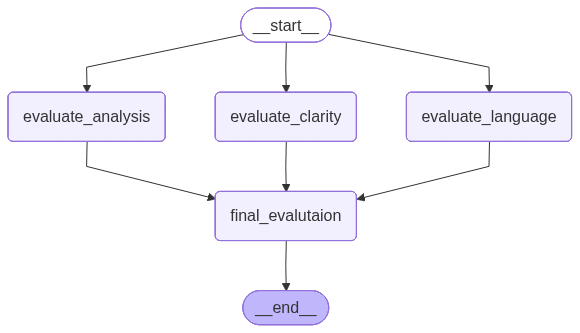

In [26]:
graph.compile()

In [27]:
workflow = graph.compile()

In [28]:
essay = """  Isuffered from a bad conscience before the case even began. My patient was in his late 70s, partially blind from narrow-angle glaucoma. He had undergone a colonoscopy a few days before and now needed emergency abdominal surgery for a perforated bowel. Before his colonoscopy, he’d had a slight fever, which the surgical team – including myself, the anaesthesiologist – had dismissed, but which later proved to be an early sign of sepsis. Two voices now vied for supremacy in my head. The first asked: Why did you overlook his fever? The second replied: How could I have foreseen what would happen? The first shot back: A smart doctor is only a smart doctor if he does foresee things. It doesn’t take a smart doctor not to foresee things. Anyone can do that.

The man was on several intravenous drugs called ‘vasopressors’, which cause the heart to eject more blood and the small arteries to squeeze down, thereby raising blood pressure. Without the drugs the man would die.

I told the man my plan was to place a breathing tube in his windpipe while he was still awake, as the sedation normally used to put patients to sleep would cause his blood pressure to crash. He offered no response. His eyes sitting in his grey, haggard face were remote and sad, as though overflowing with all the mute loneliness that preys upon a solitary individual close to death inside a hospital.

I numbed his throat with local anaesthetic. His sorrowful glance was filled with entreaty as I inserted the flexible scope into his mouth. When I manoeuvred the scope past his throat, he jerked his head from side to side. As I went deeper, he bucked with a pained expression on his face, squinting his eyes and contorting his mouth, his illness having prevented me from numbing his windpipe beforehand.

Was my inflicting of pain unethical? The field of bioethics arose in the 1960s to answer such questions. But it had nothing new to say in my case. The philosophy of utilitarianism, which justifies inflicting pain on a sick, speechless patient to save that patient’s life, had conquered everyday medical practice long before bioethics came along."""

In [29]:
initial_state={
    'essay': essay,
}
workflow.invoke(initial_state)


{'essay': '  Isuffered from a bad conscience before the case even began. My patient was in his late 70s, partially blind from narrow-angle glaucoma. He had undergone a colonoscopy a few days before and now needed emergency abdominal surgery for a perforated bowel. Before his colonoscopy, he’d had a slight fever, which the surgical team – including myself, the anaesthesiologist – had dismissed, but which later proved to be an early sign of sepsis. Two voices now vied for supremacy in my head. The first asked: Why did you overlook his fever? The second replied: How could I have foreseen what would happen? The first shot back: A smart doctor is only a smart doctor if he does foresee things. It doesn’t take a smart doctor not to foresee things. Anyone can do that.\n\nThe man was on several intravenous drugs called ‘vasopressors’, which cause the heart to eject more blood and the small arteries to squeeze down, thereby raising blood pressure. Without the drugs the man would die.\n\nI told t